Pon la explicación de confidence acá al inicio del notebook. Así, se aplica a la vida real, pones que "un médico debe verlo si la confianza es baja; si es alta, por otro lado, se puede confiar más en el modelo"

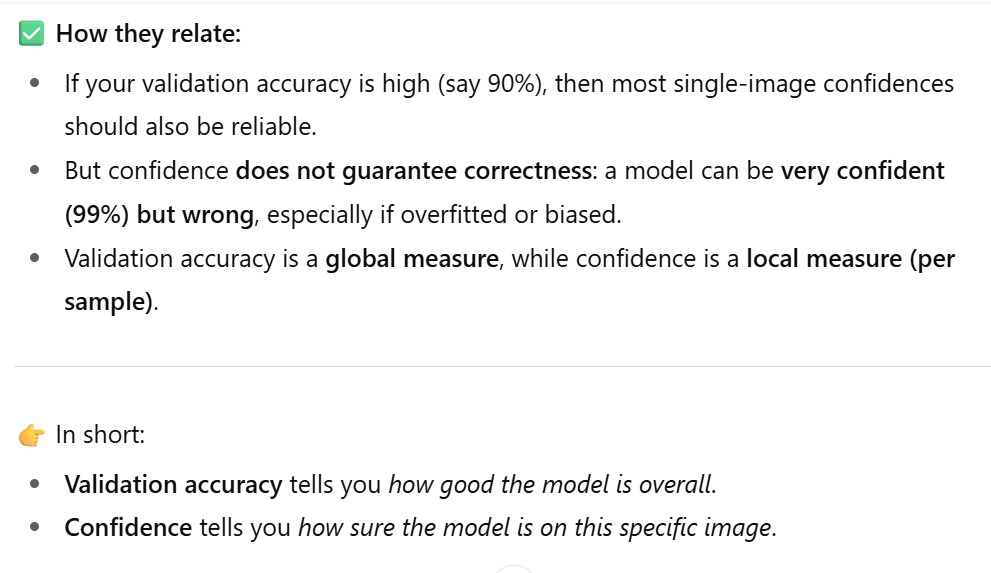


In [2]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import os
from PIL import Image


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [10]:

# --- Section 1: Define paths and parameters ---

# IMPORTANT: Replace this with the path to your saved model file (.h5)
# This file was generated by the training script.
model_path = "/content/drive/MyDrive/Mis estudios /BBS/Woxsen/alzheimers_cnn_model_20250823-130451.h5"
# IMPORTANT: Replace this with the path to the image you want to predict
# This should be a single image of a brain scan.
image_to_predict = "/content/drive/MyDrive/Mis estudios /BBS/Woxsen/test/test/Three.avif"

# Ensure these match the values used during model training
img_height, img_width = 224, 224
class_names = ["Mild Dementia", "Moderate Dementia", "Non Demented", "Very mild Dementia"]

# --- Section 2: Load the Model and Make a Prediction ---

def predict_on_image(model_path, image_path):
    """
    Loads a saved Keras model and makes a prediction on a single image.

    Args:
        model_path (str): The file path to the saved .h5 model.
        image_path (str): The file path to the image to predict on.
    """

    # Check if the model file exists
    if not os.path.exists(model_path):
        print(f"Error: Model file not found at '{model_path}'")
        return

    # Check if the image file exists
    if not os.path.exists(image_path):
        print(f"Error: Image file not found at '{image_path}'")
        return

    print("Loading model...")
    # Load the trained model from disk
    model = load_model(model_path)
    print("Model loaded successfully.")

    print(f"\nMaking prediction on '{image_path}'...")
    try:
        # Load the image and resize it to the required size
        img = tf.keras.utils.load_img(
            image_path, target_size=(img_height, img_width)
        )

        # Convert the image to a numpy array
        img_array = tf.keras.utils.img_to_array(img)

        # Expand dimensions to create a batch of size 1
        img_array = tf.expand_dims(img_array, 0)

        # Normalize pixel values to the range [0,1]
        img_array = img_array / 255.0

        # Run the prediction
        predictions = model.predict(img_array)

        # Apply softmax to convert logits into probabilities
        score = tf.nn.softmax(predictions[0])

        # Get the index of the class with the highest probability
        predicted_class_index = np.argmax(score)

        # Map the index to the actual class label
        predicted_class = class_names[predicted_class_index]

        # Extract the confidence score (highest probability)
        confidence = np.max(score)

        print("\n--- Prediction Result ---")
        print(f"Predicted Class: {predicted_class}")
        print(f"Confidence: {100*confidence:.2f}%")

    except Exception as e:
        # Catch and print any error during prediction
        print(f"An error occurred during prediction: {e}")

# --- Main execution block ---
if __name__ == "__main__":
    # Run prediction on the specified image
    predict_on_image(model_path, image_to_predict)

Loading model...


Model loaded successfully.

Making prediction on '/content/drive/MyDrive/Mis estudios /BBS/Woxsen/test/test/Three.avif'...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step

--- Prediction Result ---
Predicted Class: Non Demented
Confidence: 47.16%
